# Maken generieren

## Brain mask

In [77]:
import numpy as np
import matplotlib.pyplot as plt

data_for_mask = np.load('MetabMaps/Lesion_GT/water_amp_Lesion_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_mask)              # ignoriert NaNs
threshold = 0.01 * mx
brain_mask = (data_for_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
brain_mask[np.isnan(data_for_mask)] = 0

# Lesion mask small

In [ ]:
import nibabel as nib
import numpy as np

# NIfTI laden
nii = nib.load("Lesion_lr.nii")

# als NumPy-Array (float64)
Lesion_mask = nii.get_fdata()

Lesion_mask = np.swapaxes(Lesion_mask, -1, 0)

print(Lesion_mask.shape, Lesion_mask.dtype)

# Lac mask

In [78]:
data_for_Les_mask = np.load('MetabMaps/Lesion_GT/Lac_amp_Lesion_GT_Orig.npy')[...,-1]

mx = np.nanmax(data_for_Les_mask)              # ignoriert NaNs
threshold = 0.1 * mx
Lesion_mask = (data_for_Les_mask > threshold).astype(np.uint8)

# optional: NaNs explizit auf 0 setzen
Lesion_mask[np.isnan(data_for_Les_mask)] = 0

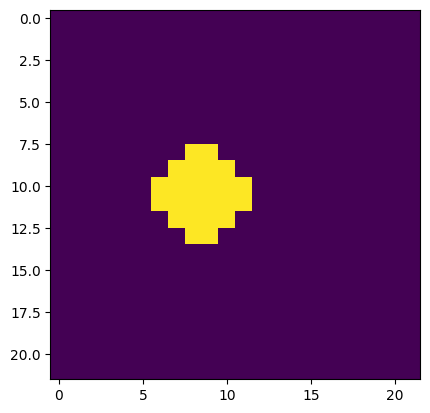

In [79]:
z = 13

plt.imshow(Lesion_mask[z,...])

# Define helper Function for RMSE over time

In [80]:
import os
import numpy as np

def load_metab_map(root, method, metabolite, suffix="Orig"):
    """
    Loads: {root}/{method}/{metabolite}_amp_{method}_{suffix}.npy
    """
    fname = f"{metabolite}_amp_{method}_{suffix}.npy"
    path = os.path.join(root, method, fname)
    return np.load(path)

def load_multiple_metab_maps(root, methods, metabolite, suffix="Orig"):
    """
    methods: List of methods 

    returns: List of Metab Maps
    """
    return [load_metab_map(root, m, metabolite, suffix) for m in methods]

def relative_rmse(gt, pred, mask, eps=1e-12):
    """
    gt, pred: arrays with shape (x,y,z)
    mask: boolean or {0,1} array broadcastable to gt without time OR with time
    returns: rRMSE
    """

    mask = mask.astype(bool) & np.isfinite(gt) & np.isfinite(pred)
    rmse = np.sqrt(np.mean((gt[mask] - pred[mask])**2))/(np.max(gt[mask])-np.min(gt[mask]))

    return rmse

def relative_rmse_time(gt, pred, mask, eps=1e-12):
    """
    Returns relative RMSE as a function of time (last index)
    """
    T = gt.shape[-1]
    RMSE = []

    for i in range(0,T):
        RMSE.append(relative_rmse(gt[..., i], pred[..., i], mask, eps))

    return RMSE

def relative_rmse_time_stats(gt, preds, mask, eps=1e-12):
    """
    preds: list of predictions with same shape as gt

    returns:
        mean_rmse_time, std_rmse_time
    """
    rmses = np.stack([relative_rmse_time(gt, p, mask, eps) for p in preds], axis=0)
    return rmses.mean(axis=0), rmses.std(axis=0)

# ---------- helper ----------
def compute_mean_std_rrmse_time(root, metab, mask, gt_method, rep_methods, suffix="Orig", eps=1e-12):
    """
    rep_methods: dict label -> list of method-folders (reps)
    returns: dict label -> (mean(T,), std(T,))
    """
    gt = load_metab_map(root, gt_method, metab, suffix)

    out = {}
    for label, reps in rep_methods.items():
        preds = load_multiple_metab_maps(root, reps, metab, suffix)
        mean_t, std_t = relative_rmse_time_stats(gt, preds, mask, eps)
        out[label] = (np.asarray(mean_t), np.asarray(std_t))
    return out




Metabo = "Lac" 
MASK = Lesion_mask # brain_mask

# Noisy_Reps = ["Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy"]
# Deep_Reps = ["Lesion_Double_deep_tMPPCA_5D", "Lesion_Double_tMPPCA_5D", "Lesion_Double_deep_tMPPCA_5D"]
# tMPPCA_Reps = ["Lesion_Double_tMPPCA_5D", "Lesion_Double_Noisy", "Lesion_Double_tMPPCA_5D"]

# GT_Lac = load_metab_map("MetabMaps", "Lesion_GT", f"{Metabo}")


# Noisy_Lac = load_metab_map("MetabMaps", "Lesion_Double_Noisy", f"{Metabo}")
# Deep_Lac = load_metab_map("MetabMaps", "Lesion_Double_deep_tMPPCA_5D", f"{Metabo}")
# tMPPCA_Lac = load_metab_map("MetabMaps", "Lesion_Double_tMPPCA_5D", f"{Metabo}")

# Noisy = relative_rmse_time(GT_Lac, Noisy_Lac, MASK)
# Deep = relative_rmse_time(GT_Lac, Deep_Lac, MASK)
# tMPPCA = relative_rmse_time(GT_Lac, tMPPCA_Lac, MASK)


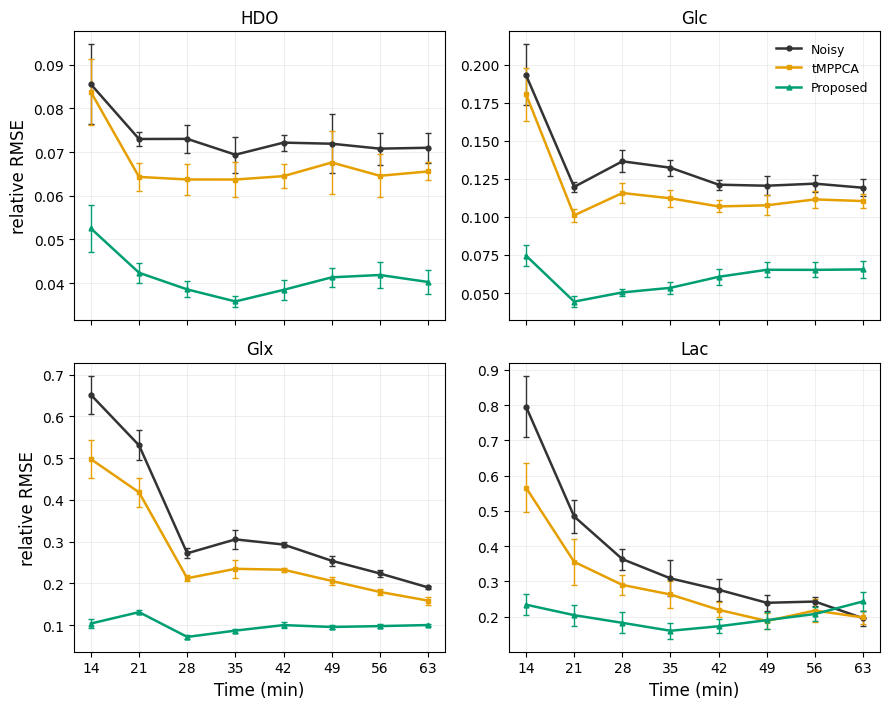

In [81]:
# ---------- USER SETTINGS ----------
root = "MetabMaps"
gt_method = "Lesion_GT"
suffix = "Orig"

Metabo = "Lac"
MASK = Lesion_mask  # oder brain_mask

Noisy_Reps  = ["Lesion_noisy_1", "Lesion_noisy_2", "Lesion_noisy_3", "Lesion_noisy_4", "Lesion_noisy_5", "Lesion_noisy_6"]
Deep_Reps   = ["Lesion_deep_tmppca_1", "Lesion_deep_tmppca_2", "Lesion_deep_tmppca_3", "Lesion_deep_tmppca_4", "Lesion_deep_tmppca_5", "Lesion_deep_tmppca_6"]
tMPPCA_Reps = ["Lesion_tmppca_1", "Lesion_tmppca_2", "Lesion_tmppca_3", "Lesion_tmppca_4", "Lesion_tmppca_5", "Lesion_tmppca_6"]

rep_methods = {
    "Noisy":    Noisy_Reps,
    "tMPPCA":   tMPPCA_Reps,
    "Proposed": Deep_Reps,
}

metabs = [
    ("water", brain_mask),
    ("Glc",   brain_mask),
    ("Glx",   brain_mask),
    ("Lac",   Lesion_mask),
]

DISPLAY_NAME = {
    "water": "HDO",
    "Glc":   "Glc",
    "Glx":   "Glx",
    "Lac":   "Lac",
}

time_axis = np.array([14,21,28,35,42,49,56,63]) 

# ===================== DROP-IN REPLACEMENT (colors + legend in top-right panel) =====================
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -------------------- STYLE / COLORS (paper-like, MRI) --------------------
DEFAULT_COLORS = {
    "noisy": "#333333",          # dark gray
    "tMPPCA_5D": "#E69F00",       # orange
    "deep_tMPPCA_5D": "#009E73",  # green
}
DEFAULT_MARKERS = {
    "noisy": "o",
    "tMPPCA_5D": "s",
    "deep_tMPPCA_5D": "^",
}

def apply_example_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.grid": False,
    })

# --- Paper-like font sizes (same as your FINAL PLOT) ---
mpl.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})

apply_example_style()

# --- Map your curve labels -> style suffix keys (THIS is the key fix) ---
LABEL_TO_SUFFIX = {
    "Noisy": "noisy",
    "tMPPCA": "tMPPCA_5D",
    "Proposed": "deep_tMPPCA_5D",
}

# style registries
colors_by_suffix  = DEFAULT_COLORS
markers_by_suffix = DEFAULT_MARKERS

fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.2), sharex=True)
axes = axes.ravel()

# style numbers copied from FINAL PLOT
lw, ms, cap = 1.8, 3.5, 2
elw = 1.0

# prepare legend for the top-right panel (axes[1])
legend_labels = list(rep_methods.keys())  # ["Noisy", "tMPPCA", "Proposed"]
legend_handles = [
    Line2D([0], [0],
           color=colors_by_suffix.get(LABEL_TO_SUFFIX[lab], "k"),
           marker=markers_by_suffix.get(LABEL_TO_SUFFIX[lab], "o"),
           lw=lw, ms=ms,
           linestyle="-",
           label=lab)
    for lab in legend_labels
]

for ax, (metab, mask) in zip(axes, metabs):
    curves = compute_mean_std_rrmse_time(
        root, metab, mask,
        gt_method=gt_method,
        rep_methods=rep_methods,
        suffix=suffix
    )

    # infer T
    any_mean = next(iter(curves.values()))[0]
    T = len(any_mean)

    # x-axis: your explicit minutes
    x = np.asarray(time_axis)
    if len(x) != T:
        raise ValueError(f"time_axis length {len(x)} != T={T} for {metab}")

    # plot in consistent order of rep_methods keys
    for lab in legend_labels:
        mean_t, std_t = curves[lab]   # curves keys are "Noisy", "tMPPCA", "Proposed"
        suf = LABEL_TO_SUFFIX[lab]
        col = colors_by_suffix.get(suf, "C0")
        mk  = markers_by_suffix.get(suf, "o")

        ax.errorbar(
            x, mean_t,
            yerr=std_t,
            color=col,
            linestyle="-",
            marker=mk,
            lw=lw,
            ms=ms,
            capsize=cap,
            elinewidth=elw,
            label=lab
        )

    ax.set_title(DISPLAY_NAME.get(metab, metab))
    # y-label nur linke Spalte
    if ax in (axes[0], axes[2]):
        ax.set_ylabel("relative RMSE")
    else:
        ax.set_ylabel("")
    ax.grid(True, alpha=0.2)
    ax.set_xticks(x)

# x-label bottom row
axes[2].set_xlabel("Time (min)")
axes[3].set_xlabel("Time (min)")

# legend INSIDE the top-right subplot
axes[1].legend(handles=legend_handles, frameon=False, loc="upper right", fontsize=9)

fig.tight_layout()
plt.savefig("rrmse_timecourse_2x2.pdf", bbox_inches="tight")
plt.show()